# ARTI 406 – Image Processing
## Lab 5: Spatial Filtering – Smoothing and Sharpening

**Student Name:** Danyal Salman Alhashem  
**Student ID:** 2240002713

**Outcome #2:** Write a program that implements fundamental image processing algorithms.

This notebook contains:
- **Procedural Task #1:** Unsharp Masking
- **Assessment Task #1:** 7×7 box filter
- **Assessment Task #2:** 5×5 and 21×21 Gaussian filters
- **Assessment Task #3:** 3×3 Laplacian sharpening

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100

---
## Procedural Task #1: Unsharp Masking

Unsharp masking sharpens an image by adding back a scaled version of the *detail* (the difference between the image and a blurred copy):

**g(x,y) = f(x,y) + k · [ f(x,y) − f_blur(x,y) ]**

where k = `amount`. The lab uses `images/Parrot.png`; since that file was not provided, `images/astronaut.png` is used instead (any RGB image works).

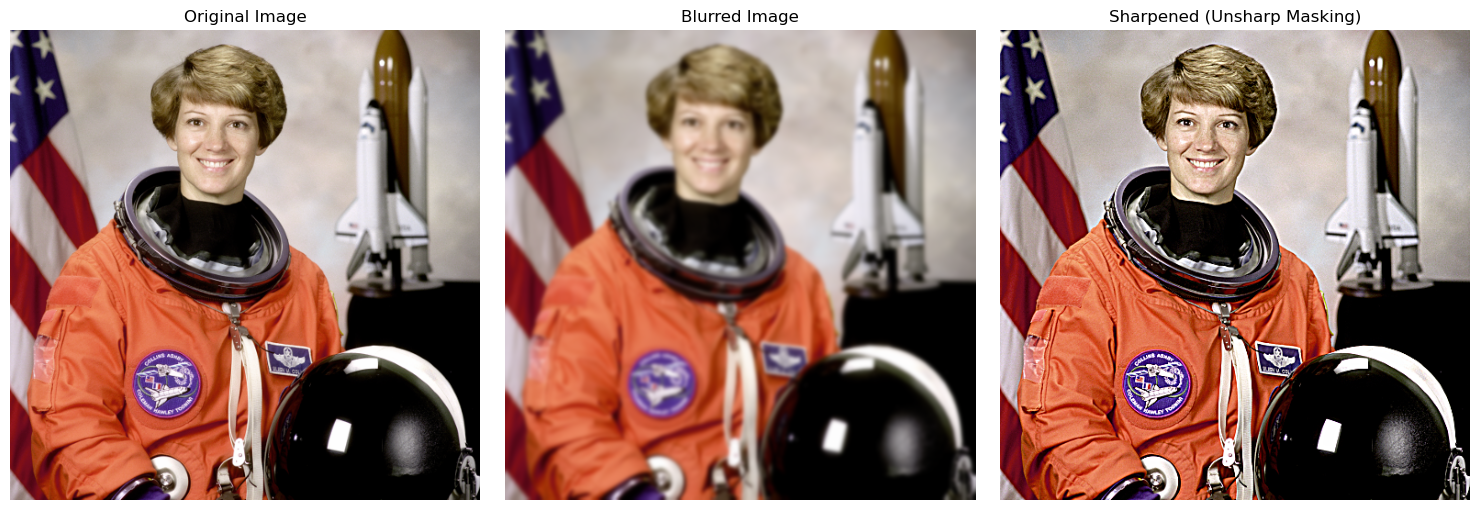

In [2]:
# Read the image
image = cv2.imread('images/astronaut.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)   # Convert from BGR to RGB

# Gaussian sigma
sigma = 2
# parameter
amount = 1.5

# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

# Plot original, blurred, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image);     ax[0].set_title("Original Image");               ax[0].axis("off")
ax[1].imshow(blurred);   ax[1].set_title("Blurred Image");                ax[1].axis("off")
ax[2].imshow(sharpened); ax[2].set_title("Sharpened (Unsharp Masking)");  ax[2].axis("off")
plt.tight_layout()
plt.show()

**Observation:** The blurred image loses fine detail (hair, fabric texture). Adding 1.5× the difference back produces a sharpened image where edges and textures are clearly more pronounced than in the original.

---
# Assessment

## Task #1: 7×7 Box Filter

A box (mean) filter replaces each pixel with the average of its neighbourhood. The 7×7 kernel is:

**K = (1/49) × (7×7 matrix of ones)**

We build the kernel explicitly and convolve it with the image using `cv2.filter2D`, then confirm the result matches OpenCV's built-in `cv2.blur`.

Identical to cv2.blur(img, (7,7)): True


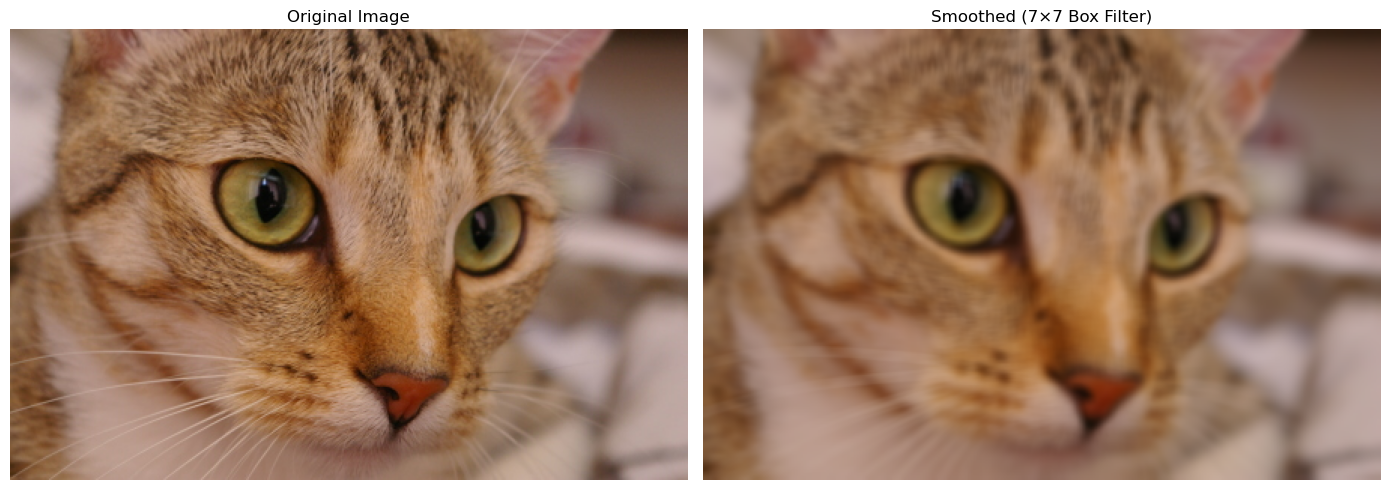

In [3]:
# Read the image
img = cv2.imread('images/cat.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 7x7 box kernel (all ones, normalised so the weights sum to 1)
box_kernel = np.ones((7, 7), np.float32) / 49

# Convolve the image with the kernel
box_smoothed = cv2.filter2D(img, -1, box_kernel)

# Sanity check against OpenCV's built-in box filter
print("Identical to cv2.blur(img, (7,7)):", np.array_equal(box_smoothed, cv2.blur(img, (7, 7))))

# Show original and smoothed side by side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(img);          ax[0].set_title("Original Image");               ax[0].axis("off")
ax[1].imshow(box_smoothed); ax[1].set_title("Smoothed (7×7 Box Filter)");    ax[1].axis("off")
plt.tight_layout()
plt.show()

**Observation:** The 7×7 averaging removes noise and fine texture (the cat's fur and whiskers become soft), but it also blurs edges uniformly since every neighbour has equal weight.

---
## Task #2: 5×5 and 21×21 Gaussian Filters

A Gaussian filter weights neighbours by distance from the centre, so it smooths more naturally than a box filter. With `sigmaX=0`, OpenCV computes σ from the kernel size:
σ = 0.3·((k−1)/2 − 1) + 0.8, giving σ = 1.1 for 5×5 and σ = 3.5 for 21×21.

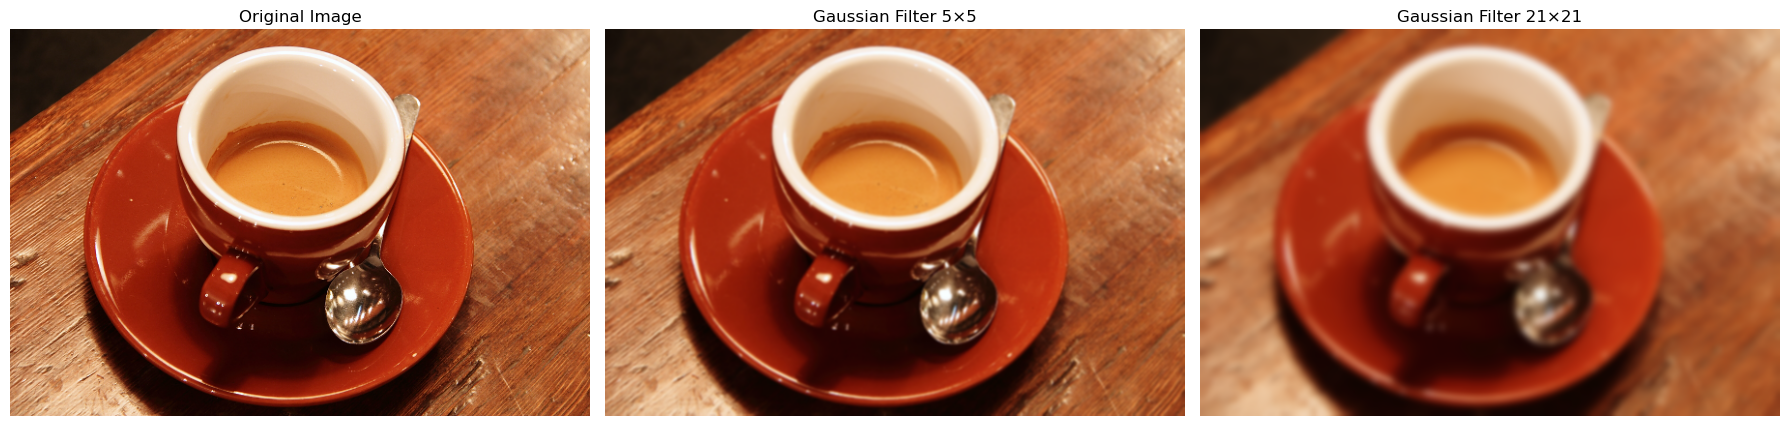

In [4]:
# Read the image
img2 = cv2.imread('images/coffee.png')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Apply 5x5 and 21x21 Gaussian filters (sigma computed automatically from kernel size)
gauss_5  = cv2.GaussianBlur(img2, (5, 5), 0)
gauss_21 = cv2.GaussianBlur(img2, (21, 21), 0)

# Show the three images side by side
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].imshow(img2);     ax[0].set_title("Original Image");            ax[0].axis("off")
ax[1].imshow(gauss_5);  ax[1].set_title("Gaussian Filter 5×5");       ax[1].axis("off")
ax[2].imshow(gauss_21); ax[2].set_title("Gaussian Filter 21×21");     ax[2].axis("off")
plt.tight_layout()
plt.show()

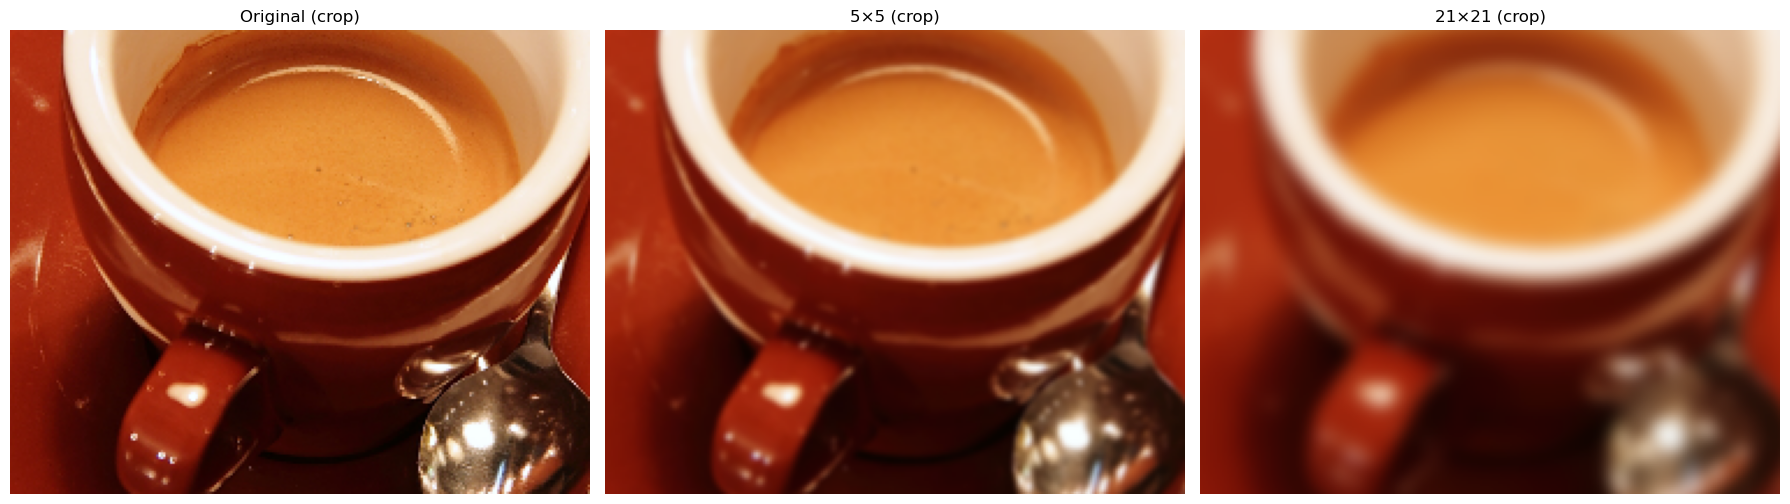

In [5]:
# Zoomed crop to make the difference easier to see
y0, y1, x0, x1 = 100, 300, 150, 400
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for a, im, t in zip(ax, [img2, gauss_5, gauss_21], ["Original (crop)", "5×5 (crop)", "21×21 (crop)"]):
    a.imshow(im[y0:y1, x0:x1]); a.set_title(t); a.axis("off")
plt.tight_layout()
plt.show()

**Observation:** The 5×5 Gaussian gives a slight softening that is barely visible at full size, while the 21×21 Gaussian (larger kernel and larger σ) blurs heavily – the latte art, cup rim and background details lose their sharpness. A larger kernel = stronger smoothing.

---
## Task #3: Sharpening with a 3×3 Laplacian

The Laplacian is a second-derivative operator that responds strongly at edges:

**∇²f = ∂²f/∂x² + ∂²f/∂y²**

With `ksize=3`, OpenCV uses the kernel `[[2, 0, 2], [0, −8, 0], [2, 0, 2]]` (for `ksize=1` it uses the classic `[[0, 1, 0], [1, −4, 1], [0, 1, 0]]`). Because the centre coefficient is negative, the image is sharpened by **subtracting** the Laplacian:

**g(x,y) = f(x,y) − ∇²f(x,y)**

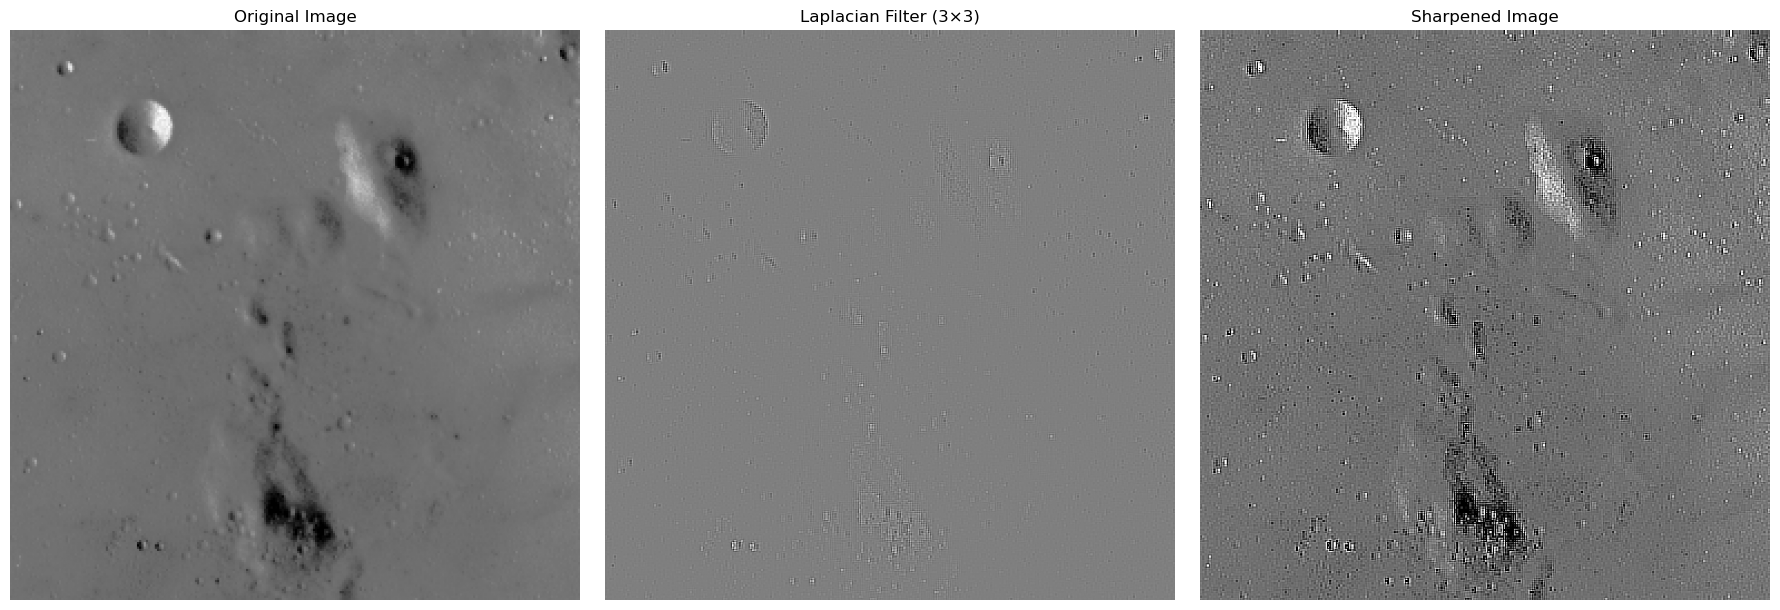

In [6]:
# 1. Read the image (grayscale)
img3 = cv2.imread('images/moon.png', cv2.IMREAD_GRAYSCALE)

# 2. Convert image to float32 (range [0,1])
image_float = img3.astype(np.float32) / 255.0

# 3. Apply the 3x3 Laplacian filter
laplacian = cv2.Laplacian(image_float, cv2.CV_32F, ksize=3)

# 4. Sharpen the image
sharpened_lap = np.clip(image_float - laplacian, 0, 1)

# 5. Plot original, Laplacian result, and sharpened image
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(image_float, cmap='gray', vmin=0, vmax=1);   ax[0].set_title("Original Image");             ax[0].axis("off")
ax[1].imshow(laplacian, cmap='gray');                     ax[1].set_title("Laplacian Filter (3×3)");     ax[1].axis("off")
ax[2].imshow(sharpened_lap, cmap='gray', vmin=0, vmax=1); ax[2].set_title("Sharpened Image");            ax[2].axis("off")
plt.tight_layout()
plt.show()

**Observation:** The Laplacian output is near zero in flat regions and has strong positive/negative responses along crater rims and edges. Subtracting it from the original boosts those edges, so the sharpened image shows crisper crater outlines and surface detail.

### Bonus: Laplacian sharpening on a colour image
The same steps applied to an RGB image (the Laplacian is computed per channel). A milder 4-neighbour kernel (`ksize=1`) is used here to avoid over-sharpening.

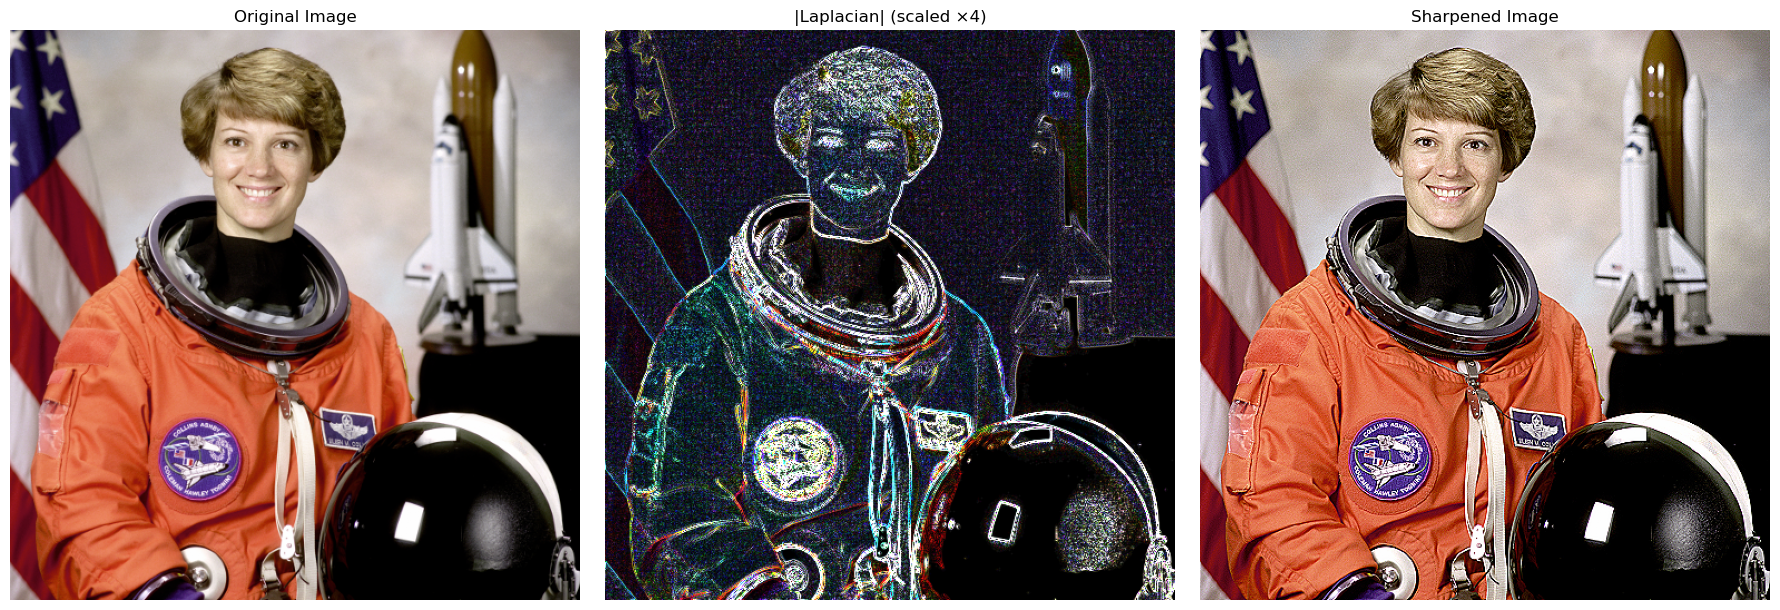

In [7]:
img4 = cv2.cvtColor(cv2.imread('images/astronaut.png'), cv2.COLOR_BGR2RGB)
f4 = img4.astype(np.float32) / 255.0
lap4 = cv2.Laplacian(f4, cv2.CV_32F, ksize=1)
sharp4 = np.clip(f4 - lap4, 0, 1)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(f4);                                    ax[0].set_title("Original Image");               ax[0].axis("off")
ax[1].imshow(np.clip(np.abs(lap4) * 4, 0, 1));       ax[1].set_title("|Laplacian| (scaled ×4)");      ax[1].axis("off")
ax[2].imshow(sharp4);                                ax[2].set_title("Sharpened Image");              ax[2].axis("off")
plt.tight_layout()
plt.show()

---
## Conclusion

- **Smoothing filters** (box, Gaussian) are low-pass filters: they average neighbouring pixels, reducing noise and detail. The box filter weights all neighbours equally; the Gaussian weights them by distance, giving a more natural blur. Larger kernels produce stronger blurring.
- **Sharpening filters** emphasise high-frequency content. *Unsharp masking* adds back (image − blurred) scaled by an amount, while *Laplacian sharpening* subtracts the second derivative of the image. Both make edges and fine detail more visible, but too much sharpening amplifies noise.